# Train XGBoost model (t+1 target)
Train an XGBoost classifier on `data/processed/xgboost_t1`, using `target_t+1` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Hyperparameters are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve against the business objective.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_xgboost
from train_xgboost import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t1"
train_xgboost.set_horizon(HORIZON)
TARGET_COLUMN = train_xgboost.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset xgboost_t1 with target 'target_t+1'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,707
Validation observations: 3,753
Number of features: 30

Class distribution in training data:
  Negative: 17,379
  Positive: 1,328
  scale_pos_weight: 13.09


Best trial: 9. Best value: 0.182463: 100%|██████████| 50/50 [00:15<00:00,  3.32it/s]



Best validation PR-AUC: 0.1825
Best hyperparameters:
  learning_rate: 0.1
  max_depth: 4
  min_child_weight: 50
  subsample: 0.85
  colsample_bytree: 0.7
  gamma: 0.5
  reg_alpha: 0.01
  reg_lambda: 5
  scale_pos_weight: 13.086596385542169


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
9,9,0.182463,2026-08-31 10:21:28.812951,2026-08-31 10:21:29.040744,0 days 00:00:00.227793,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
42,42,0.182463,2026-08-31 10:21:39.118085,2026-08-31 10:21:39.429393,0 days 00:00:00.311308,0.7,1.0,0.1,4,50,0.01,5,0.85,COMPLETE
34,34,0.182463,2026-08-31 10:21:36.142911,2026-08-31 10:21:36.470408,0 days 00:00:00.327497,0.7,1.0,0.1,4,50,0.01,5,0.85,COMPLETE
33,33,0.182463,2026-08-31 10:21:35.820353,2026-08-31 10:21:36.138902,0 days 00:00:00.318549,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
45,45,0.182463,2026-08-31 10:21:40.024759,2026-08-31 10:21:40.331867,0 days 00:00:00.307108,0.7,1.0,0.1,4,50,0.01,5,0.85,COMPLETE
31,31,0.182463,2026-08-31 10:21:35.151315,2026-08-31 10:21:35.466241,0 days 00:00:00.314926,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
41,41,0.182463,2026-08-31 10:21:38.799389,2026-08-31 10:21:39.116152,0 days 00:00:00.316763,0.7,1.0,0.1,4,50,0.01,5,0.85,COMPLETE
43,43,0.182463,2026-08-31 10:21:39.432804,2026-08-31 10:21:39.749564,0 days 00:00:00.316760,0.7,1.0,0.1,4,50,0.01,5,0.85,COMPLETE
14,14,0.182463,2026-08-31 10:21:30.137548,2026-08-31 10:21:30.377541,0 days 00:00:00.239993,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
26,26,0.176561,2026-08-31 10:21:33.171854,2026-08-31 10:21:33.604010,0 days 00:00:00.432156,0.7,0.5,0.1,4,50,0.01,10,0.85,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

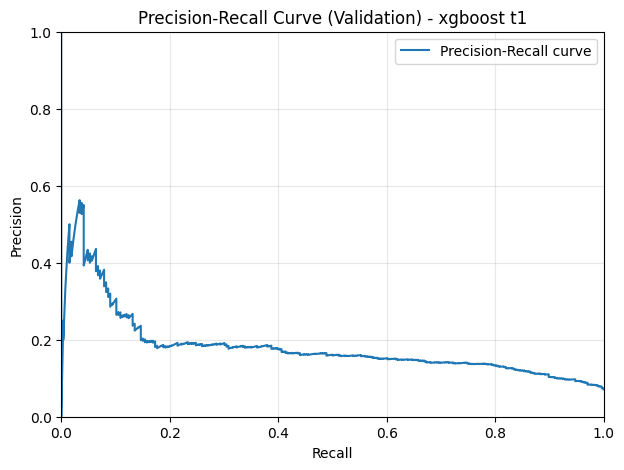

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - xgboost {HORIZON}",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.5].head(20)

,threshold,precision,recall
3714,0.781688,0.500000,0.041353
3715,0.783999,0.523810,0.041353
3716,0.784514,0.550000,0.041353
3717,0.784640,0.526316,0.037594
3718,0.784707,0.555556,0.037594
3719,0.784841,0.529412,0.033835
3720,0.785280,0.562500,0.033835
3721,0.785827,0.533333,0.030075
3722,0.790905,0.500000,0.026316
3728,0.800207,0.500000,0.015038


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

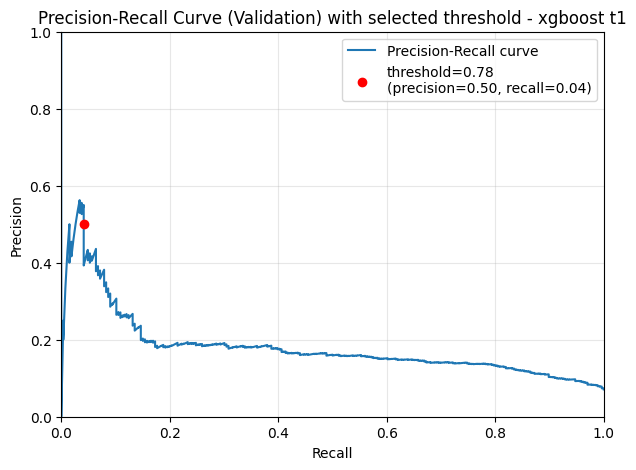

In [6]:
SELECTED_THRESHOLD = 0.781688

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - xgboost {HORIZON}",
);

## Final evaluation

In [7]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.227757,0.513514,0.028614,0.054208,0.477778,0.032380
val,0.182463,0.500000,0.041353,0.076389,0.300000,0.101504
test,0.155630,0.259259,0.037634,0.065728,0.288889,0.069892


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [8]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\xgboost_t1.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/xgboost_t1.joblib')